In [1]:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
import gc
from mnp.ingestion.loader import load_endes
from IPython.display import display

from mnp.utils.profiler import centrar_notebook
centrar_notebook()

# Carga de historial desde 2007 para RECH6
history = load_endes(
        year=range(2007, 2025),
        module="anthropometry",
        record="rech6",
        meta=True
    )

frames = []
latest_year_labels = {}
col_labels_hist = {}
value_labels_history = {}

for year in sorted(list(history.keys())):
    year_df, year_meta = history.pop(year)
    frames.append(year_df.assign(year=year))
    latest_year_labels.update(year_meta.column_names_to_labels)
    col_labels_hist[year] = year_meta.column_names_to_labels
    value_labels_history[year] = year_meta.variable_value_labels

df_rech6 = pd.concat(frames, ignore_index=True)
del frames
gc.collect()

all_cols = set()
for cols in col_labels_hist.values():
    all_cols.update(cols)

print(f"Registros RECH6 totales: {len(df_rech6)}")
print(f"Columnas RECH6 totales: {df_rech6.shape[1]}")
df_rech6.head(3)

OpenBLAS WARNING - could not determine the L2 cache size on this system, assuming 256k
2026-06-10 02:56:05.197 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /workspace


2026-06-10 02:56:05.491 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH6.SAV desde Modulo74 [Alias: rech6]
2026-06-10 02:56:05.694 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH6.SAV desde Modulo74 [Alias: rech6]
2026-06-10 02:56:05.959 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH6.SAV desde Modulo74 [Alias: rech6]
2026-06-10 02:56:06.239 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH6.SAV desde Modulo74 [Alias: rech6]
2026-06-10 02:56:06.452 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH6.sav desde Modulo74 [Alias: rech6]
2026-06-10 02:56:06.861 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH6.sav desde Modulo74 [Alias: rech6]
2026-06-10 02:56:07.257 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH6.SAV desde Modulo74 [Alias: rech6]
2026-06-10 02:56:07.671 | INFO     | mnp.ingesti

,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,HC9,HC10,HC11,HC12,HC13,HC15,HC16,HC17,HC18,HC19,HC27,HC30,HC31,HC32,HC33,HC51,HC52,HC53,HC55,HC56,HC57,HC58,HC60,HC61,HC62,HC63,HC64,HC68,HC70,HC71,HC72,HC73,year,f,ID1,HV005A,HC56A,HC57A
0,1 10,3.0,20.0,96.0,766.0,177.0,-210.0,9201.0,830.0,-138.0,8524.0,3494.0,-39.0,9664.0,0.0,1.0,17.0,29.0,3.0,2005.0,2.0,7.0,2003.0,1243.0,1.0,2.0,2.0,NaN,4.0,NaN,NaN,NaN,2.0,3.0,3.0,NaN,1.0,3.0,-214.0,-92.0,18.0,57.0,2007,NaN,NaN,NaN,NaN,NaN
1,1 22,5.0,28.0,137.0,832.0,468.0,-168.0,9355.0,6255.0,32.0,10417.0,9145.0,137.0,11692.0,0.0,2.0,25.0,29.0,3.0,2005.0,1.0,11.0,2002.0,1235.0,1.0,2.0,1.0,111.0,0.0,100.0,3.0,NaN,2.0,1.0,5.0,101.0,3.0,1.0,-221.0,48.0,232.0,268.0,2007,NaN,NaN,NaN,NaN,NaN
2,1 34,3.0,40.0,128.0,920.0,956.0,-131.0,9481.0,948.0,-131.0,8617.0,3078.0,-50.0,9559.0,0.0,2.0,11.0,31.0,3.0,2005.0,2.0,11.0,2001.0,1223.0,1.0,2.0,2.0,NaN,4.0,NaN,NaN,NaN,2.0,3.0,2.0,NaN,1.0,3.0,-153.0,-108.0,-30.0,-15.0,2007,NaN,NaN,NaN,NaN,NaN


## 1.1. Schema Drift (Mutación de Column Labels)

In [2]:
from mnp.utils.profiler import analyze_schema_drift, print_schema_drift_report

all_cols_sch, stable_schema, mutated_schema = analyze_schema_drift(col_labels_hist)
print_schema_drift_report(all_cols_sch, stable_schema, mutated_schema)

REPORTE GLOBAL DE MUTACIÓN DE DESCRIPCIONES DE COLUMNAS (COLUMN LABELS)

Total de columnas detectadas: 47

Descripciones estables: 5
f (Apariciones: 1 años)
  - Años 2013                       : None
ID1 (Apariciones: 6 años)
  - Años 2019-2024                  : Año
HV005A (Apariciones: 1 años)
  - Años 2020                       : Factor mediciones niño
HC56A (Apariciones: 1 años)
  - Años 2024                       : Nivel de hemoglobina ajustado por altitud (g/dl-1 decimal) NUEVA DIRECTRIZ OMS 2024/RM 251-2024-MINSA
HC57A (Apariciones: 1 años)
  - Años 2024                       : Nivel de anemia NUEVA DIRECTRIZ OMS 2024/RM 251-2024-MINSA


Descripciones mutadas: 42
HHID (Apariciones: 18 años)
  - Años 2007-2008, 2011, 2013-2017 : Case Identification
  - Años 2009-2010, 2012            : Identificación del hogar
  - Años 2018                       : Identificación Cuestionario del Hogar
  - Años 2019-2024                  : Identificación Cuestionario Individual
HC0 (Apariciones: 1

## 1.2. Schema Drift (Mutación de Value Labels)

In [3]:
from mnp.utils.profiler import analyze_val_drift, print_val_drift_report

all_val_cols, stable_val_labels, mutated_val_labels = analyze_val_drift(value_labels_history)
print_val_drift_report(all_val_cols, stable_val_labels, mutated_val_labels, latest_year_labels=latest_year_labels)

REPORTE GLOBAL DE MUTACIÓN DE ETIQUETAS DE VALORES (2007 - 2024)

Total de columnas con mapeo de valores detectadas: 28

Etiquetas de valores estables: 1
HC57A - Nivel de anemia NUEVA DIRECTRIZ OMS 2024/RM 251-2024-MINSA (Apariciones: 1 años)
  - Años 2024                        : 1.0 (Grave) | 2.0 (Moderar) | 3.0 (Leve) | 4.0 (Sin anemia)


Etiquetas de valores mutadas: 27
HC4 - Talla/Edad percentil (Apariciones: 18 años)
  - Años 2007-2008, 2011, 2013-2018  : 9998.0 (Flagged cases)
  - Años 2009-2010, 2012, 2019-2024  : 9998.0 (Casos marcados)
HC5 - Talla/Edad Desviación Estándar (Apariciones: 18 años)
  - Años 2007-2008, 2011, 2013-2018  : 9998.0 (Flagged cases)
  - Años 2009-2010, 2012, 2019-2024  : 9998.0 (Casos marcados)
HC6 - Talla/Edad porcentaje de la mediana de referencia (Apariciones: 18 años)
  - Años 2007-2008, 2011, 2013-2018  : 99998.0 (Flagged cases)
  - Años 2009-2010, 2012             : 99998.0 (Casos marcados)
  - Años 2019-2024                   : 9998.0 (Casos marc

## 1.5. Matriz Histórica de Variables (Evolución del Schema)

In [4]:
# Filas = Años, Columnas = Variables
df_history_matrix = pd.DataFrame(col_labels_hist).T.sort_index()

# Reemplazamos los valores por el nombre de la propia variable (si existe) o vacío si no existía ese año
for col in df_history_matrix.columns:
    df_history_matrix[col] = df_history_matrix[col].where(df_history_matrix[col].isna(), col)

df_history_matrix = df_history_matrix.fillna("")

display(df_history_matrix)

,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,HC9,HC10,HC11,HC12,HC13,HC15,HC16,HC17,HC18,HC19,HC27,HC30,HC31,HC32,HC33,HC51,HC52,HC53,HC55,HC56,HC57,HC58,HC60,HC61,HC62,HC63,HC64,HC68,HC70,HC71,HC72,HC73,f,ID1,HV005A,HC56A,HC57A
2007,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,HC9,HC10,HC11,HC12,HC13,HC15,HC16,HC17,HC18,HC19,HC27,HC30,HC31,HC32,HC33,HC51,HC52,HC53,HC55,HC56,HC57,HC58,HC60,HC61,HC62,HC63,HC64,HC68,HC70,HC71,HC72,HC73,,,,,
2008,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,HC9,HC10,HC11,HC12,HC13,HC15,HC16,HC17,HC18,HC19,HC27,HC30,HC31,HC32,HC33,HC51,HC52,HC53,HC55,HC56,HC57,HC58,HC60,HC61,HC62,HC63,HC64,HC68,HC70,HC71,HC72,HC73,,,,,
2009,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,HC9,HC10,HC11,HC12,HC13,HC15,HC16,HC17,HC18,HC19,HC27,HC30,HC31,HC32,HC33,HC51,HC52,HC53,HC55,HC56,HC57,HC58,HC60,HC61,HC62,HC63,HC64,HC68,HC70,HC71,HC72,HC73,,,,,
2010,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,HC9,HC10,HC11,HC12,HC13,HC15,HC16,HC17,HC18,HC19,HC27,HC30,HC31,HC32,HC33,HC51,HC52,HC53,HC55,HC56,HC57,HC58,HC60,HC61,HC62,HC63,HC64,HC68,HC70,HC71,HC72,HC73,,,,,
2011,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,HC9,HC10,HC11,HC12,HC13,HC15,HC16,HC17,HC18,HC19,HC27,HC30,HC31,HC32,HC33,HC51,HC52,HC53,HC55,HC56,HC57,HC58,HC60,HC61,HC62,HC63,HC64,HC68,HC70,HC71,HC72,HC73,,,,,
2012,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,HC9,HC10,HC11,HC12,HC13,HC15,HC16,HC17,HC18,HC19,HC27,HC30,HC31,HC32,HC33,HC51,HC52,HC53,HC55,HC56,HC57,HC58,HC60,HC61,HC62,HC63,HC64,HC68,HC70,HC71,HC72,HC73,,,,,
2013,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,HC9,HC10,HC11,HC12,HC13,HC15,HC16,HC17,HC18,HC19,HC27,HC30,HC31,HC32,HC33,HC51,HC52,HC53,HC55,HC56,HC57,HC58,HC60,HC61,HC62,HC63,HC64,HC68,HC70,HC71,HC72,HC73,,,,,
2014,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,HC9,HC10,HC11,HC12,HC13,HC15,HC16,HC17,HC18,HC19,HC27,HC30,HC31,HC32,HC33,HC51,HC52,HC53,HC55,HC56,HC57,HC58,HC60,HC61,HC62,HC63,HC64,HC68,HC70,HC71,HC72,HC73,,,,,
2015,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,HC9,HC10,HC11,HC12,HC13,HC15,HC16,HC17,HC18,HC19,HC27,HC30,HC31,HC32,HC33,HC51,HC52,HC53,HC55,HC56,HC57,HC58,HC60,HC61,HC62,HC63,HC64,HC68,HC70,HC71,HC72,HC73,,,,,
2016,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,HC8,HC9,HC10,HC11,HC12,HC13,HC15,HC16,HC17,HC18,HC19,HC27,HC30,HC31,HC32,HC33,HC51,HC52,HC53,HC55,HC56,HC57,HC58,HC60,HC61,HC62,HC63,HC64,HC68,HC70,HC71,HC72,HC73,,,,,


## 2. Master Data Dictionary (Reporte Combinado)

In [5]:
import pandas as pd
from mnp.utils.profiler import (
    analyze_logical_types, metric_latest_label, metric_logical_type, 
    metric_pandas_dtype, metric_has_value_labels, metric_nulls, 
    metric_years_present, metric_total_years
)

# 💡 ENFOQUE HÍBRIDO: IDs locales o conocidos
known_ids = ["CASEID", "MIDX", "HC0"]
logical_types_dict = analyze_logical_types(df_rech6, all_cols, value_labels_history, col_labels_hist, forced_ids=known_ids)

# 1. El DataFrame base son las variables originales
df_report = pd.DataFrame(index=sorted(list(all_cols)))
df_report.index.name = "Variable"

# 2. Los "Enchufes" explícitos usando el map() nativo de Pandas
df_report["Latest Column Label"] = df_report.index.map(lambda c: metric_latest_label(c, latest_year_labels))
df_report["Tipo Lógico"]         = df_report.index.map(lambda c: metric_logical_type(c, logical_types_dict))
df_report["Pandas Dtype"]        = df_report.index.map(lambda c: metric_pandas_dtype(c, df_rech6.dtypes))
df_report["Value Labels"]        = df_report.index.map(lambda c: metric_has_value_labels(c, value_labels_history))
df_report["Años Presente"]       = df_report.index.map(lambda c: metric_years_present(c, col_labels_hist))
df_report["Total Años"]          = df_report.index.map(lambda c: metric_total_years(c, col_labels_hist))
df_report["% Nulos"]             = df_report.index.map(lambda c: metric_nulls(c, df_rech6))

df_report.sort_values(by=["Tipo Lógico", "% Nulos"], ascending=[True, False], inplace=True)
display(df_report)

,Latest Column Label,Tipo Lógico,Pandas Dtype,Value Labels,Años Presente,Total Años,% Nulos
Variable,,,,,,,
HC58,Está de acuerdo con enviar los datos a un especialista,Categorical,float64,X,2007-2024,18,100.0
HC57A,Nivel de anemia NUEVA DIRECTRIZ OMS 2024/RM 251-2024-MINSA,Categorical,float64,X,2024,1,93.8
HC57,Nivel de anemia RM 363-2022-MINSA,Categorical,float64,X,2007-2024,18,12.0
HC55,Resultado de medir (hemoglobina),Categorical,float64,X,2007-2024,18,8.0
HC51,Número de orden del padre o responsable,Categorical,float64,X,2007-2024,18,7.7
HC52,Leyó la declaración de consentimiento,Categorical,float64,X,2007-2024,18,7.7
HC61,El nivel educativo más alto de la madre,Categorical,float64,X,2007-2024,18,2.9
HC68,Nivel educativo más alto (CS para informe preliminar y final),Categorical,float64,X,2007-2024,18,2.9
HC15,El niño se midió acostado o de pie,Categorical,float64,X,2007-2024,18,2.7


## 3. Análisis de Nulos por Tipo Lógico
Al agrupar por Tipo Lógico universal (en lugar de categorías de negocio manuales), podemos aplicar reglas de limpieza automáticas más adelante.


ANÁLISIS DE EVOLUCIÓN DE NULOS: CATEGORICAL


year,Etiqueta,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
HC10,Peso/Talla percentil,9.989411,10.244719,6.492900,3.159397,1.826341,0.000000,2.778358,3.238114,2.691268,3.518208,1.178668,1.255764,1.250960,2.453988,2.128314,1.913129,1.644614,1.586989
HC11,Peso/Talla Desviación Estándar,9.989411,10.244719,6.492900,3.159397,1.826341,0.000000,2.778358,3.238114,2.691268,3.518208,1.178668,1.255764,1.250960,2.453988,2.128314,1.913129,1.644614,1.586989
HC12,Peso/Talla Porcentaje de la mediana de referencia,9.989411,10.244719,6.492900,3.159397,1.826341,0.000000,2.778358,3.238114,2.691268,3.518208,1.178668,1.255764,1.250960,2.453988,2.128314,1.913129,1.644614,1.586989
HC13,Razón por la cual el niño no se midió,0.088246,0.046525,0.009342,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HC15,El niño se midió acostado o de pie,9.971761,10.272634,6.474215,3.149205,1.826341,2.472877,2.778358,3.238114,2.683433,3.522617,1.174221,1.218709,1.223863,2.453988,2.097533,1.881912,1.616660,1.542632
HC27,Sexo,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HC30,Mes de nacimiento del niño,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HC31,Año de nacimiento del niño,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HC33,Fecha de información completa,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HC4,Talla/Edad percentil,10.060007,10.300549,6.548954,3.251121,1.836777,0.948099,2.799248,3.306594,2.773534,3.553479,1.178668,1.255764,1.250960,2.453988,2.128314,1.913129,1.644614,1.586989


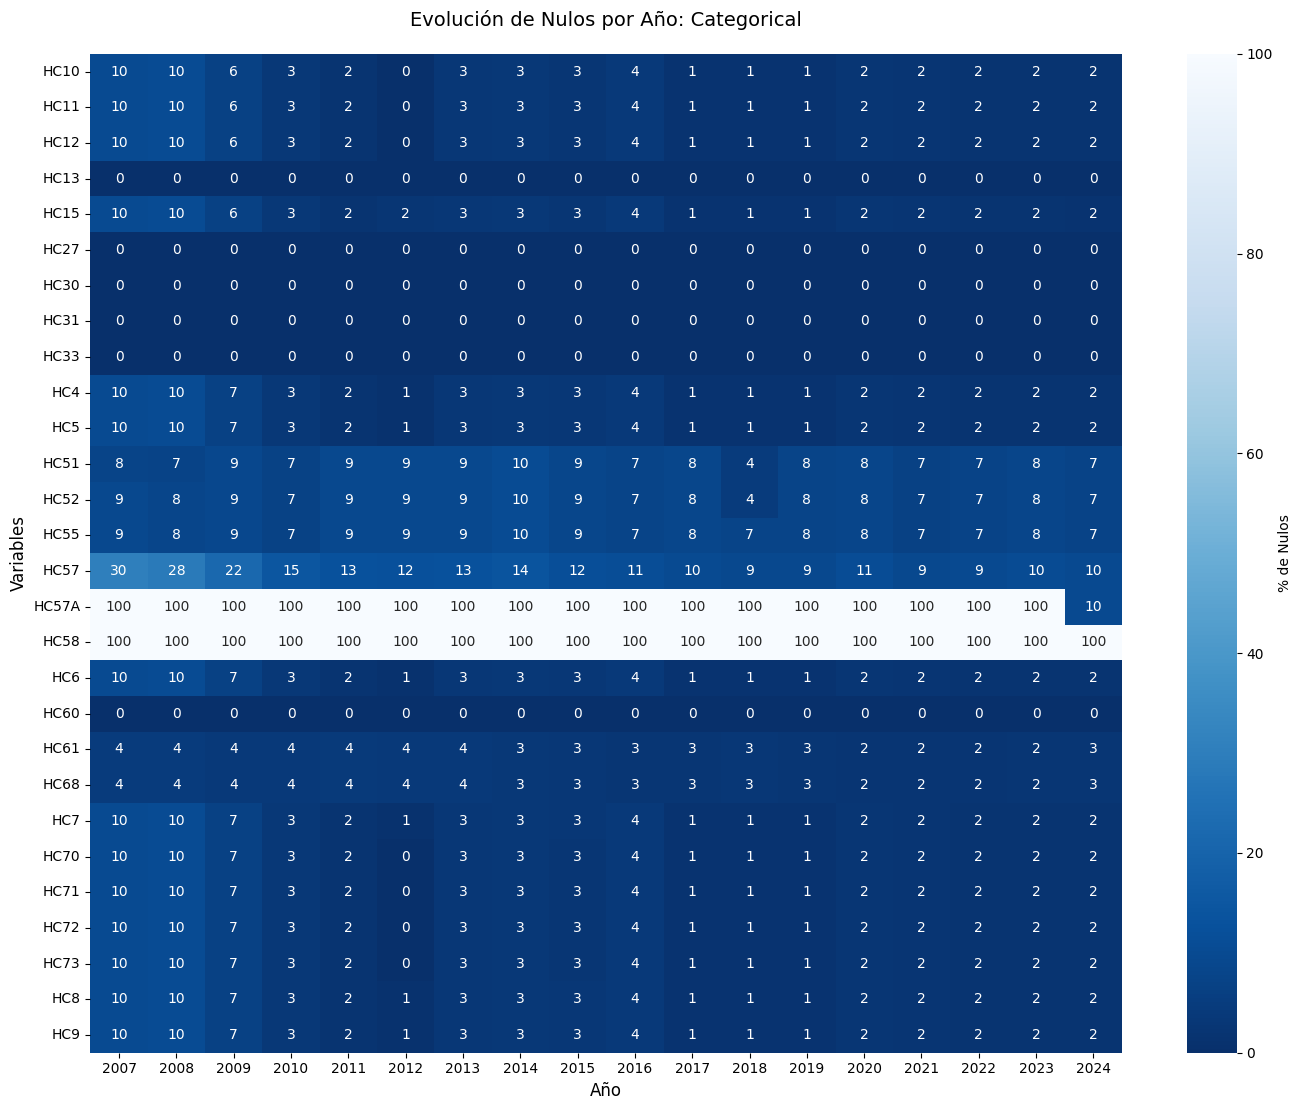

In [7]:
from mnp.utils.profiler import analyze_nulls_evolution

analyze_nulls_evolution(
    df=df_rech6, 
    cols=logical_types_dict.get("Categorical", []), 
    group_name="Categorical", 
    latest_year_labels=latest_year_labels, 
    cmap="Blues_r", 
    figsize=(14, 8)
)



ANÁLISIS DE EVOLUCIÓN DE NULOS: NUMERICAL


year,Etiqueta,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
HC1,Edad en meses,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HC16,Día de nacimiento del niño,0.741264,1.125896,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HC17,Date measured (day),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
HC18,Date measured (month),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
HC19,Año de la medición,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HC2,Peso en kilogramos (1 dec.),8.895164,9.444496,6.109865,2.996331,1.701106,2.404457,2.673909,3.218548,2.632507,3.487347,1.160877,1.222826,1.223863,2.431813,2.093136,1.877453,1.616660,1.542632
HC3,Altura en centímetros (1 dec.),9.971761,10.198195,6.474215,3.149205,1.826341,2.472877,2.778358,3.238114,2.683433,3.513799,1.178668,1.251647,1.250960,2.453988,2.128314,1.913129,1.635296,1.586989
HC32,Fecha de nacimiento (cmc),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HC53,Nivel de hemoglobina (g/dl-1 decimal),30.091776,28.175305,21.562033,14.563799,12.794824,12.960610,12.857740,13.950303,11.591648,11.114540,9.989770,9.263834,9.294134,10.835982,9.027747,9.498751,10.245061,9.521932
HC56,Nivel de hemoglobina ajustado por altitud (g/dl-1 decimal) RM 363-2022-MINSA,30.091776,28.175305,21.562033,14.563799,12.794824,12.608738,12.857740,13.950303,11.591648,11.114540,9.989770,9.263834,9.294134,10.835982,9.027747,9.498751,10.245061,9.521932


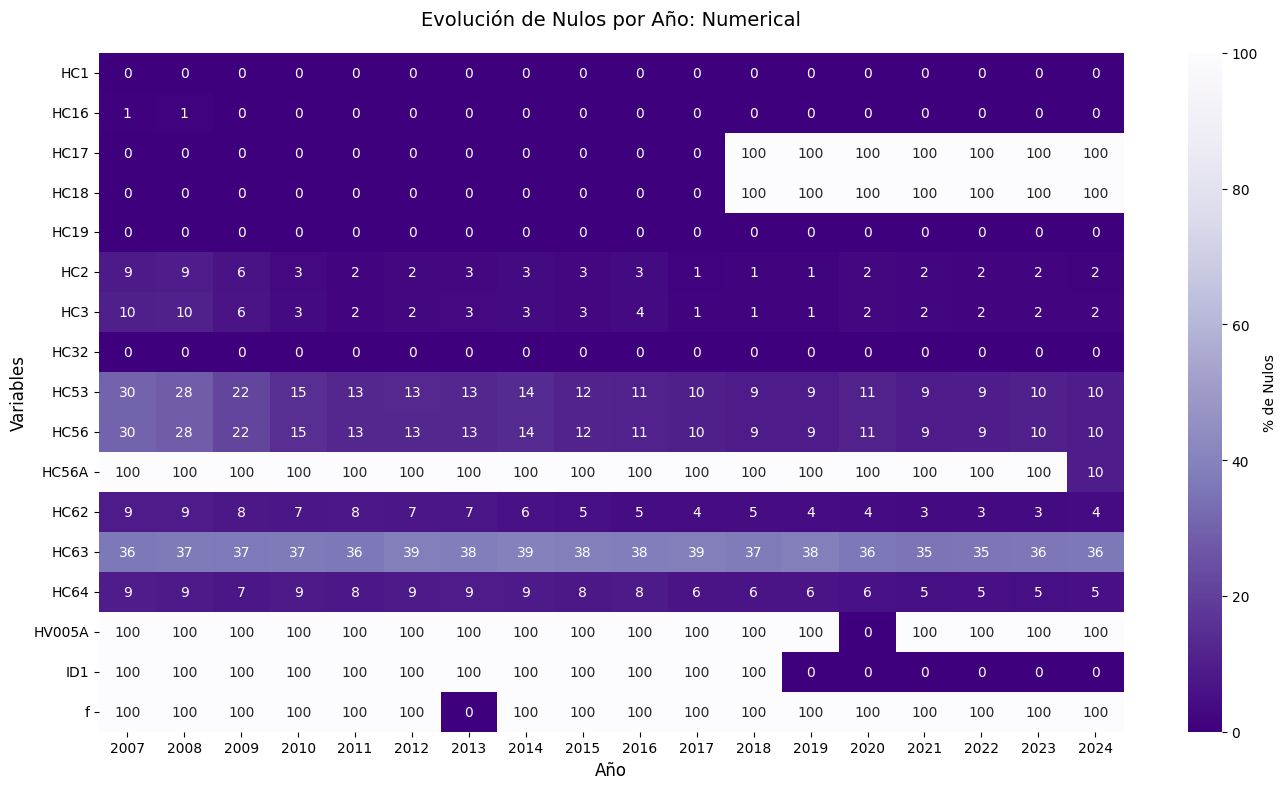

In [8]:
from mnp.utils.profiler import analyze_nulls_evolution

analyze_nulls_evolution(
    df=df_rech6, 
    cols=logical_types_dict.get("Numerical", []), 
    group_name="Numerical", 
    latest_year_labels=latest_year_labels, 
    cmap="Purples_r", 
    figsize=(14, 8)
)



ANÁLISIS DE EVOLUCIÓN DE NULOS: IDENTIFIER


year,Etiqueta,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
HC0,Número de orden en el hogar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HHID,Identificación Cuestionario Individual,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


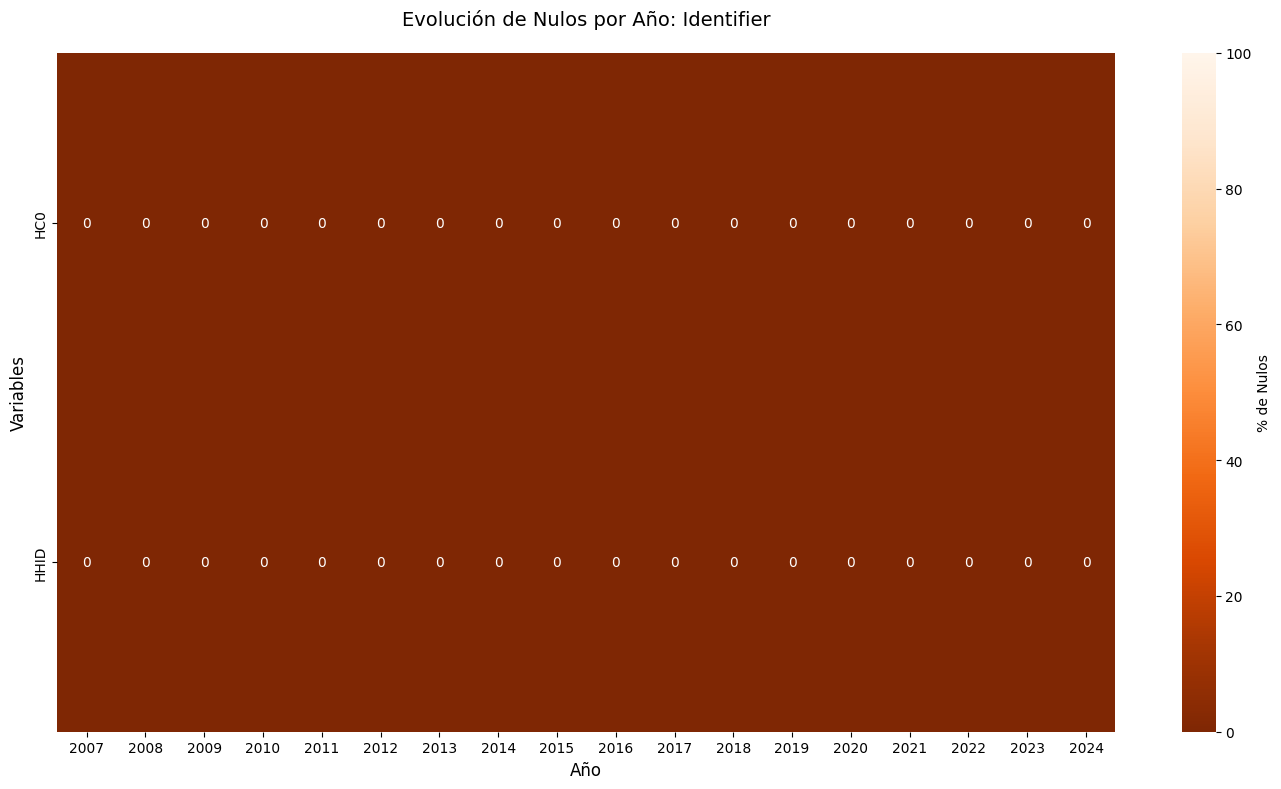

In [9]:
from mnp.utils.profiler import analyze_nulls_evolution

analyze_nulls_evolution(
    df=df_rech6, 
    cols=logical_types_dict.get("Identifier", []), 
    group_name="Identifier", 
    latest_year_labels=latest_year_labels, 
    cmap="Oranges_r", 
    figsize=(14, 8)
)
